# PANGENOME ANALYSIS

In [17]:
.libPaths("~/R/lib")

library(ape)
library(pheatmap)
library(readr)
library(dplyr)
library(stringr)
library(ggplot2)
library(tibble)
library(purrr)
library(ggrepel)
library(pheatmap)
library(tidyr)
library(ggtree)
library(vegan) 
library(rlang)
library(ggtreeExtra)
library(ggnewscale)
library(patchwork)
library(cowplot)


Attaching package: ‘cowplot’


The following object is masked from ‘package:patchwork’:

    align_plots




### TANZANIA - our data

In [2]:
# FILES

pangenome_dir <- "../../results_for_analysis/pangenome/tanzania"

# metadata with correct st and passed samples
meta <- read_tsv("../../results_for_analysis/metadata/metadata_tidy_tanzania.tsv")

# read roary files
gene_pa <- read_tsv(
  file.path(pangenome_dir, "gene_presence_absence.Rtab"),
  show_col_types = FALSE
)

treefile <- read.tree(file.path(pangenome_dir, "core_genome_tree.nwk"))


Rows: 53 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (7): sample, date, sample_type, host, region, animal_contact, species
dbl (1): ST

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


total_gene_families,core_genes,accessory_genes,unique_genes
<int>,<int>,<int>,<int>
5325,1863,3462,1175


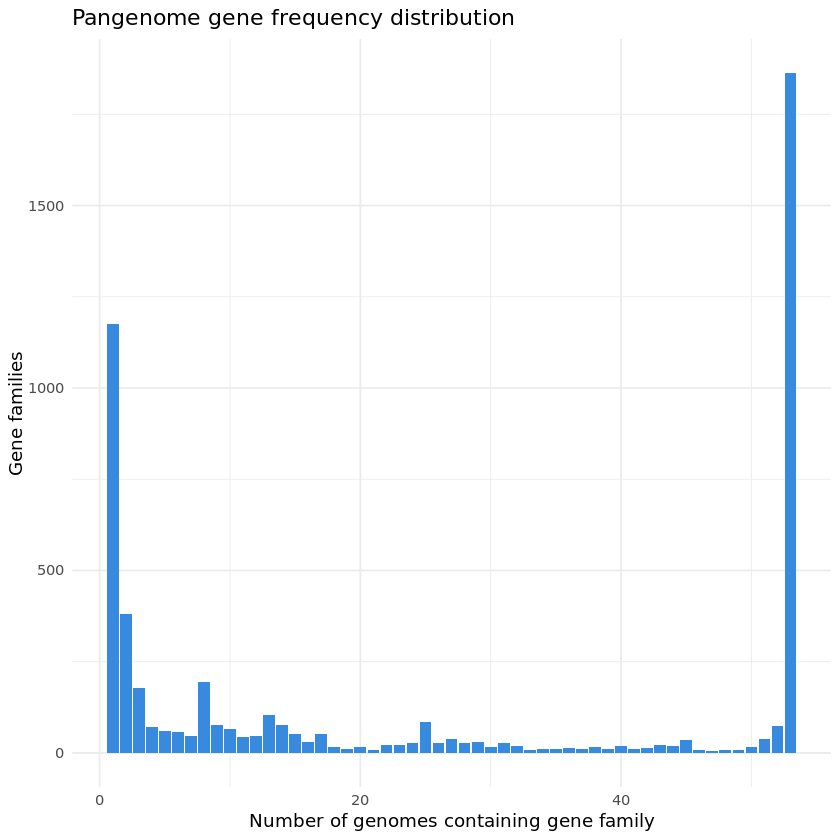

In [3]:

# first column is gene family name; remaining columns are isolates
gene_id <- gene_pa[[1]]
pa_mat <- gene_pa[, -1]
pa_mat <- as.matrix(pa_mat)
rownames(pa_mat) <- gene_id

# basic pangenome summary
n_genomes <- ncol(pa_mat)
genes_per_family <- rowSums(pa_mat > 0)

pangenome_summary <- tibble(
  total_gene_families = nrow(pa_mat),
  core_genes = sum(genes_per_family == n_genomes),
  accessory_genes = sum(genes_per_family < n_genomes),
  unique_genes = sum(genes_per_family == 1)
)

pangenome_summary

top_genes <- rownames(pa_mat)[order(genes_per_family, decreasing = TRUE)][1:min(100, nrow(pa_mat))]
# gene frequency plot
gene_freq_df <- tibble(
  genomes_with_gene = genes_per_family
) |>
  count(genomes_with_gene)

ggplot(gene_freq_df, aes(x = genomes_with_gene, y = n)) +
  geom_col(fill = "#378ADD") +
  theme_minimal() +
  labs(
    x = "Number of genomes containing gene family",
    y = "Gene families",
    title = "Pangenome gene frequency distribution"
  )



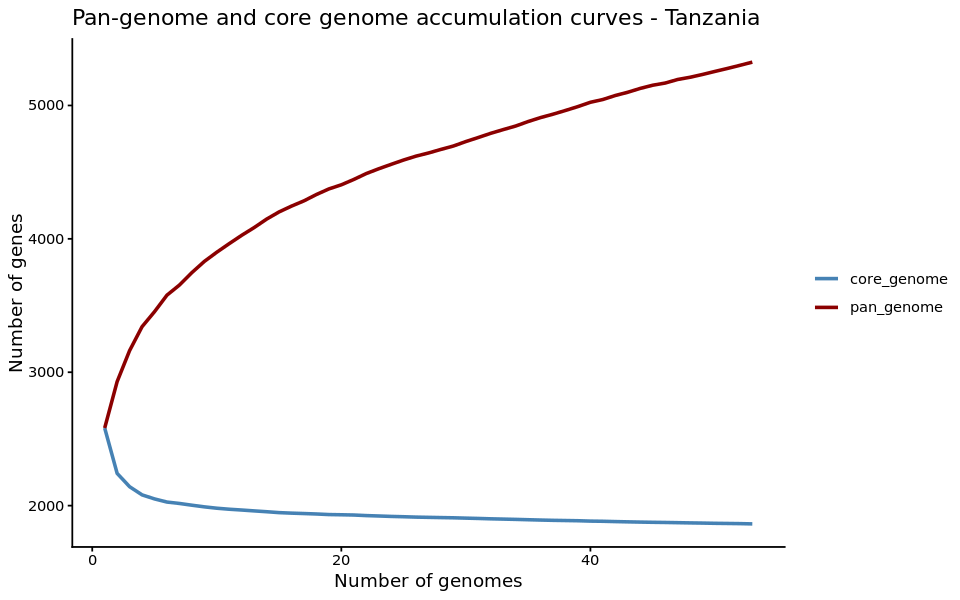

In [4]:
# pangenome accumulation curve
options(repr.plot.width = 8, repr.plot.height = 5)

set.seed(42)

pan_binary <- as.matrix(pa_mat > 0)   # genes x genomes
n_perms <- 100

pan_sum  <- numeric(ncol(pan_binary))
core_sum <- numeric(ncol(pan_binary))

for (i in seq_len(n_perms)) {
  sample_order <- sample(ncol(pan_binary))
  
  for (j in seq_along(sample_order)) {
    subset <- pan_binary[, sample_order[1:j], drop = FALSE]
    
    pan_sum[j]  <- pan_sum[j]  + sum(rowSums(subset) >= 1)
    core_sum[j] <- core_sum[j] + sum(rowSums(subset) == j)
  }
}

pan_curve  <- pan_sum / n_perms
core_curve <- core_sum / n_perms

curve_df <- tibble(
  n_genomes   = seq_len(ncol(pan_binary)),
  pan_genome  = pan_curve,
  core_genome = core_curve
) |>
  pivot_longer(-n_genomes, names_to = "type", values_to = "genes")

ggplot(curve_df, aes(x = n_genomes, y = genes, color = type)) +
  geom_line(linewidth = 1) +
  scale_color_manual(values = c(
    pan_genome = "darkred",
    core_genome = "steelblue"
  )) +
  labs(
    x = "Number of genomes",
    y = "Number of genes",
    title = "Pan-genome and core genome accumulation curves - Tanzania",
    color = NULL
  ) +
  theme_classic()

options(repr.plot.width = 12, repr.plot.height = 5)

#### Tree view

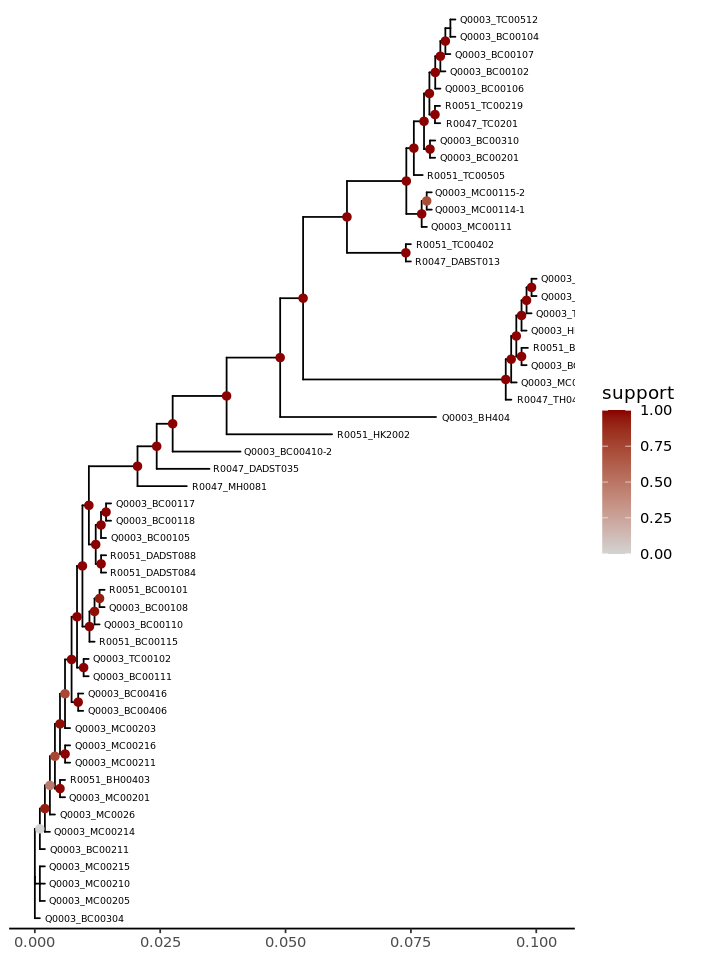

In [23]:
options(repr.plot.width = 6, repr.plot.height = 8)

treefile <- read.tree(file.path(pangenome_dir, "core_genome_tree.nwk"))

tree_mod <- treefile
tree_mod$edge.length <- tree_mod$edge.length * 3 + 0.001

# plot: show node support >= 0.7 as percent and color nodes by support
p_base_tree <- ggtree(tree_mod)

p_tree <- p_base_tree +
  geom_point2(aes(subset = !is.na(suppressWarnings(as.numeric(label))),
                  color = suppressWarnings(as.numeric(label))),
              size = 2) +
  scale_color_gradient(low = "lightgrey", high = "darkred", na.value = "grey80", name = "support") +
  geom_tiplab(aes(label = label), angle = 0, hjust = 0.1, size = 2, offset = 0.002) +
  theme_tree2() + theme(plot.margin = margin(5.5, 25, 5.5, 5.5))

p_tree

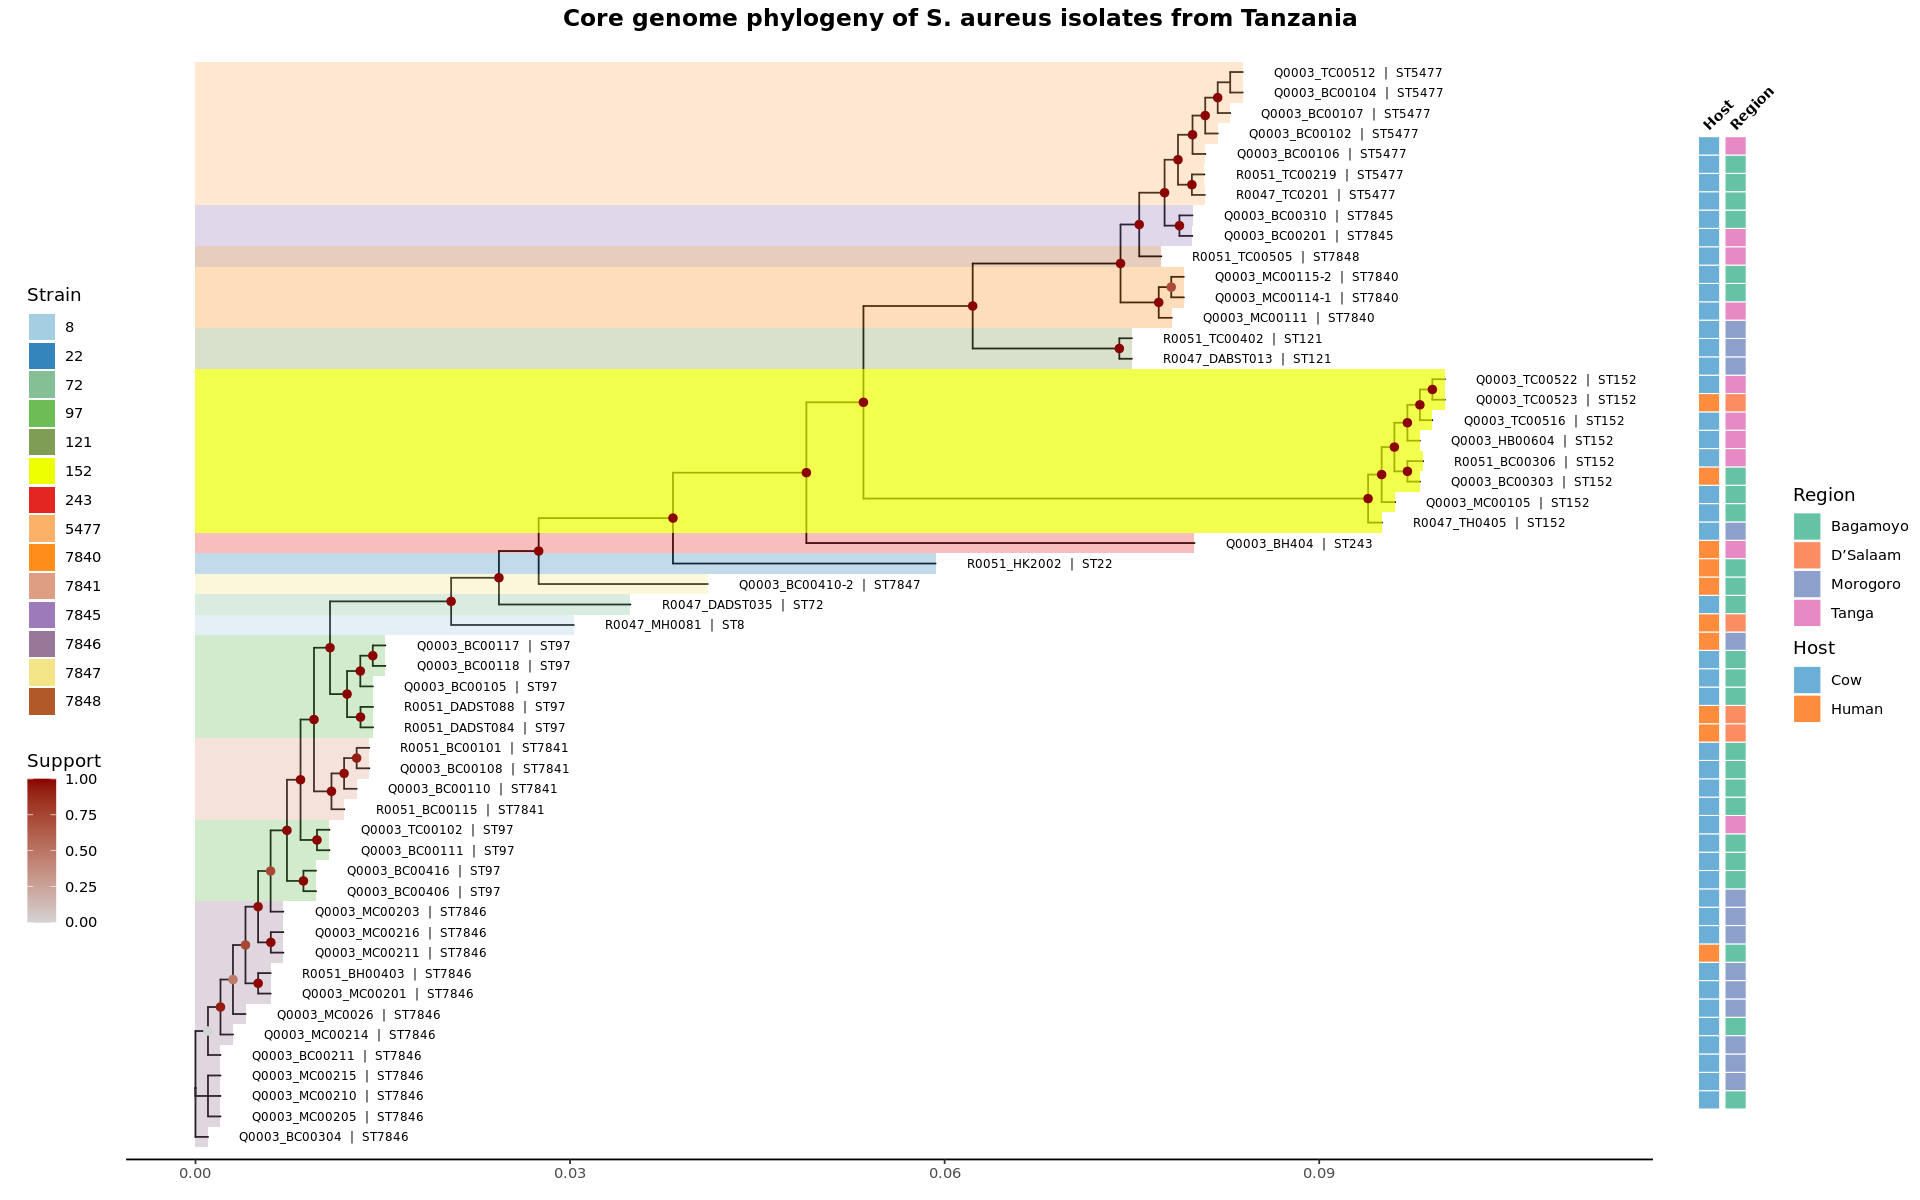

In [14]:
options(repr.plot.width = 16, repr.plot.height = 10)
library(patchwork)

st_colours <- setNames(
  colorRampPalette(RColorBrewer::brewer.pal(12, "Paired"))(nlevels(meta$ST)),
  levels(meta$ST)
)
st_colours["152"] <- "#eeff01"

host_colours   <- c("Cow" = "#6BAED6", "Human" = "#FD8D3C")
region_colours <- setNames(
  RColorBrewer::brewer.pal(max(3, nlevels(meta$region)), "Set2")[seq_len(nlevels(meta$region))],
  levels(meta$region)
)

# ── tree prep ─────────────────────────────────────────────────────────────────
tree_mod <- treefile
tree_mod$edge.length <- tree_mod$edge.length * 3 + 0.001

p_base <- ggtree(tree_mod) %<+% meta

tip_data <- p_base$data %>%
  filter(isTip) %>%
  left_join(meta, by = c("label" = "sample")) %>%
  arrange(y) %>%
  mutate(tip_label = paste0(label, "  |  ST", ST.y),
         st_alpha  = ifelse(ST.y == "152", 0.7, 0.3))

# ── build tree with labels, get x range ───────────────────────────────────────
p_base2 <- ggtree(tree_mod) %<+% tip_data
x_max <- max(tip_data$x) + 0.001

p_tree <- p_base2 +
  geom_rect(
    data = tip_data,
    aes(xmin = 0, xmax = x,
        ymin = y - 0.5, ymax = y + 0.5,
        fill = ST.y, alpha = st_alpha),
    inherit.aes = FALSE
  ) +
  scale_fill_manual(values = st_colours, name = "Strain") +
  scale_alpha_identity() +
  new_scale_color() +
  geom_point2(
    aes(subset = !is.na(suppressWarnings(as.numeric(label))),
        color  = suppressWarnings(as.numeric(label))),
    size = 2
  ) +
  scale_color_gradient(low = "lightgrey", high = "darkred",
                       na.value = "grey80", name = "Support") +
  geom_tiplab(aes(label = tip_label), size = 2.5, offset = 0.002) +
  xlim(0, x_max * 1.1) + 
  theme_tree2() +
  theme(plot.margin     = margin(5.5, 5, 5.5, 5.5),
        legend.position = "left")

# ── annotation plot ───────────────────────────────────────────────────────────
y_min <- min(tip_data$y) - 0.5
y_max <- max(tip_data$y) + 0.5

annot_data <- tip_data %>%
  select(label, y, host = host.y, region = region.y, ST = ST.y)

p_annot <- ggplot(annot_data) +
  geom_tile(aes(x = 1, y = y, fill = host),
            width = 0.8, color = "white", linewidth = 0.3) +
  scale_fill_manual(values = host_colours, name = "Host") +
  new_scale_fill() +
  geom_tile(aes(x = 2, y = y, fill = region),
            width = 0.8, color = "white", linewidth = 0.3) +
  scale_fill_manual(values = region_colours, name = "Region") +
  # angled column labels on top
  annotate("text", x = 1, y = y_max + 0.3, label = "Host",
           angle = 45, hjust = 0, vjust = 0, size = 3, fontface = "bold") +
  annotate("text", x = 2, y = y_max + 0.3, label = "Region",
           angle = 45, hjust = 0, vjust = 0, size = 3, fontface = "bold") +
  coord_cartesian(ylim = c(y_min, y_max + 2), clip = "off") +
  scale_x_continuous(breaks = NULL, expand = c(0.5, 0.5)) +
  theme_void() +
  theme(legend.position = "right",
        plot.margin     = margin(5.5, 5.5, 5.5, 0))

# ── combine ───────────────────────────────────────────────────────────────────
p_tree + p_annot +
  plot_layout(widths = c(5, 0.4)) +
  plot_annotation(
    title = "Core genome phylogeny of S. aureus isolates from Tanzania",
    theme = theme(plot.title = element_text(size = 14, face = "bold", hjust = 0.5))
  )

Accessory genes: 3462 


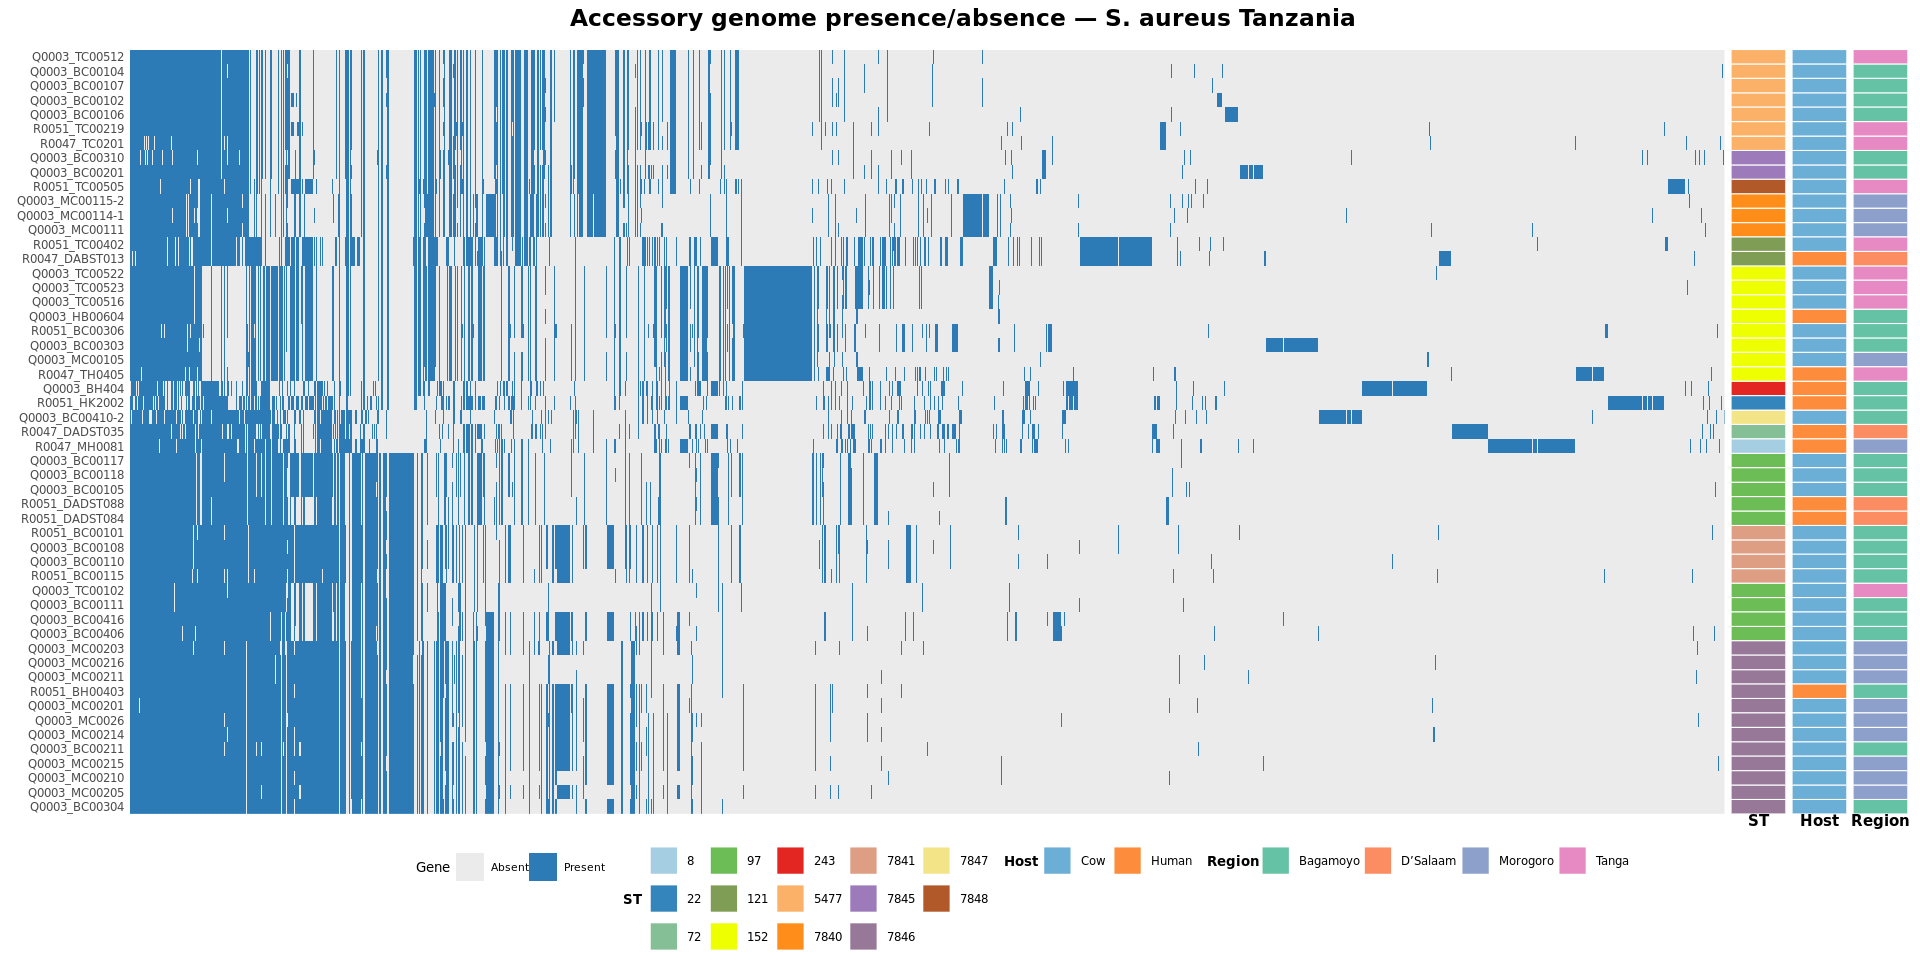

In [ ]:
options(repr.plot.width = 16, repr.plot.height = 8)
library(patchwork)
library(tidyr)
library(dplyr)

# ── load ──────────────────────────────────────────────────────────────────────
gpa <- read.delim(file.path(pangenome_dir, "gene_presence_absence.Rtab"),
                  row.names = 1, check.names = FALSE)

# ── match sample order to tree ────────────────────────────────────────────────
samples_in_order <- tip_order[tip_order %in% colnames(gpa)]
gpa_ordered      <- gpa[, samples_in_order]

# ── keep only accessory genes ─────────────────────────────────────────────────
freq          <- rowSums(gpa_ordered) / ncol(gpa_ordered)
gpa_accessory <- gpa_ordered[freq > 0 & freq < 1, ]   # exclude core (=1) and absent (=0)

cat("Accessory genes:", nrow(gpa_accessory), "\n")

# ── sort genes by frequency (core-like → rare, left → right) ─────────────────
gene_freq  <- rowSums(gpa_accessory)
gpa_sorted <- gpa_accessory[order(gene_freq, decreasing = TRUE), ]

# ── long format ───────────────────────────────────────────────────────────────
gpa_long <- gpa_sorted %>%
  tibble::rownames_to_column("gene") %>%
  pivot_longer(-gene, names_to = "sample", values_to = "present") %>%
  mutate(
    sample  = factor(sample, levels = samples_in_order),
    gene    = factor(gene,   levels = rownames(gpa_sorted)),
    present = factor(present)
  )

# ── heatmap ───────────────────────────────────────────────────────────────────
p_heatmap <- ggplot(gpa_long, aes(x = gene, y = sample, fill = present)) +
  geom_tile(color = NA) +
  scale_fill_manual(values = c("0" = "grey92", "1" = "#05497d"),
                    labels = c("Absent", "Present"), name = "Gene") +
  scale_x_discrete(expand = c(0, 0)) +
  scale_y_discrete(expand = c(0, 0), limits = rev) +
  theme_minimal(base_size = 8) +
  theme(
    axis.text.x     = element_blank(),
    axis.text.y     = element_text(size = 7),
    axis.ticks      = element_blank(),
    axis.title      = element_blank(),
    panel.grid      = element_blank(),
    legend.position = "bottom",
    plot.margin     = margin(5.5, 2, 0, 5.5)
  )

# ── annotation strips ─────────────────────────────────────────────────────────
annot_ordered <- meta %>%
  filter(sample %in% samples_in_order) %>%
  mutate(label = factor(sample, levels = samples_in_order))

annot_theme <- theme_void() +
  theme(
    axis.title.x    = element_text(size = 9, angle = 0, vjust = 1,
                                   hjust = 0.5, face = "bold"),
    legend.position = "bottom",
    legend.text     = element_text(size = 7),
    legend.title    = element_text(size = 8, face = "bold"),
    plot.margin     = margin(0, 2, 0, 2)
  )

p_st <- ggplot(annot_ordered, aes(y = label, x = 1, fill = factor(ST))) +
  geom_tile(color = "white", linewidth = 0.3) +
  scale_fill_manual(values = st_colours, name = "ST") +
  scale_y_discrete(expand = c(0, 0), limits = rev) +
  scale_x_continuous(expand = c(0, 0)) +
  labs(x = "ST") + annot_theme

p_host <- ggplot(annot_ordered, aes(y = label, x = 1, fill = host)) +
  geom_tile(color = "white", linewidth = 0.3) +
  scale_fill_manual(values = host_colours, name = "Host") +
  scale_y_discrete(expand = c(0, 0), limits = rev) +
  scale_x_continuous(expand = c(0, 0)) +
  labs(x = "Host") + annot_theme

p_region <- ggplot(annot_ordered, aes(y = label, x = 1, fill = region)) +
  geom_tile(color = "white", linewidth = 0.3) +
  scale_fill_manual(values = region_colours, name = "Region") +
  scale_y_discrete(expand = c(0, 0), limits = rev) +
  scale_x_continuous(expand = c(0, 0)) +
  labs(x = "Region") + annot_theme

# ── combine ───────────────────────────────────────────────────────────────────
(p_heatmap + p_st + p_host + p_region +
  plot_layout(widths = c(0.88, 0.03, 0.03, 0.03),
              guides = "collect") &
  theme(legend.position = "bottom")) +
  plot_annotation(
    title = "Accessory genome presence/absence — S. aureus Tanzania",
    theme = theme(plot.title = element_text(size = 14, face = "bold", hjust = 0.5))
  )

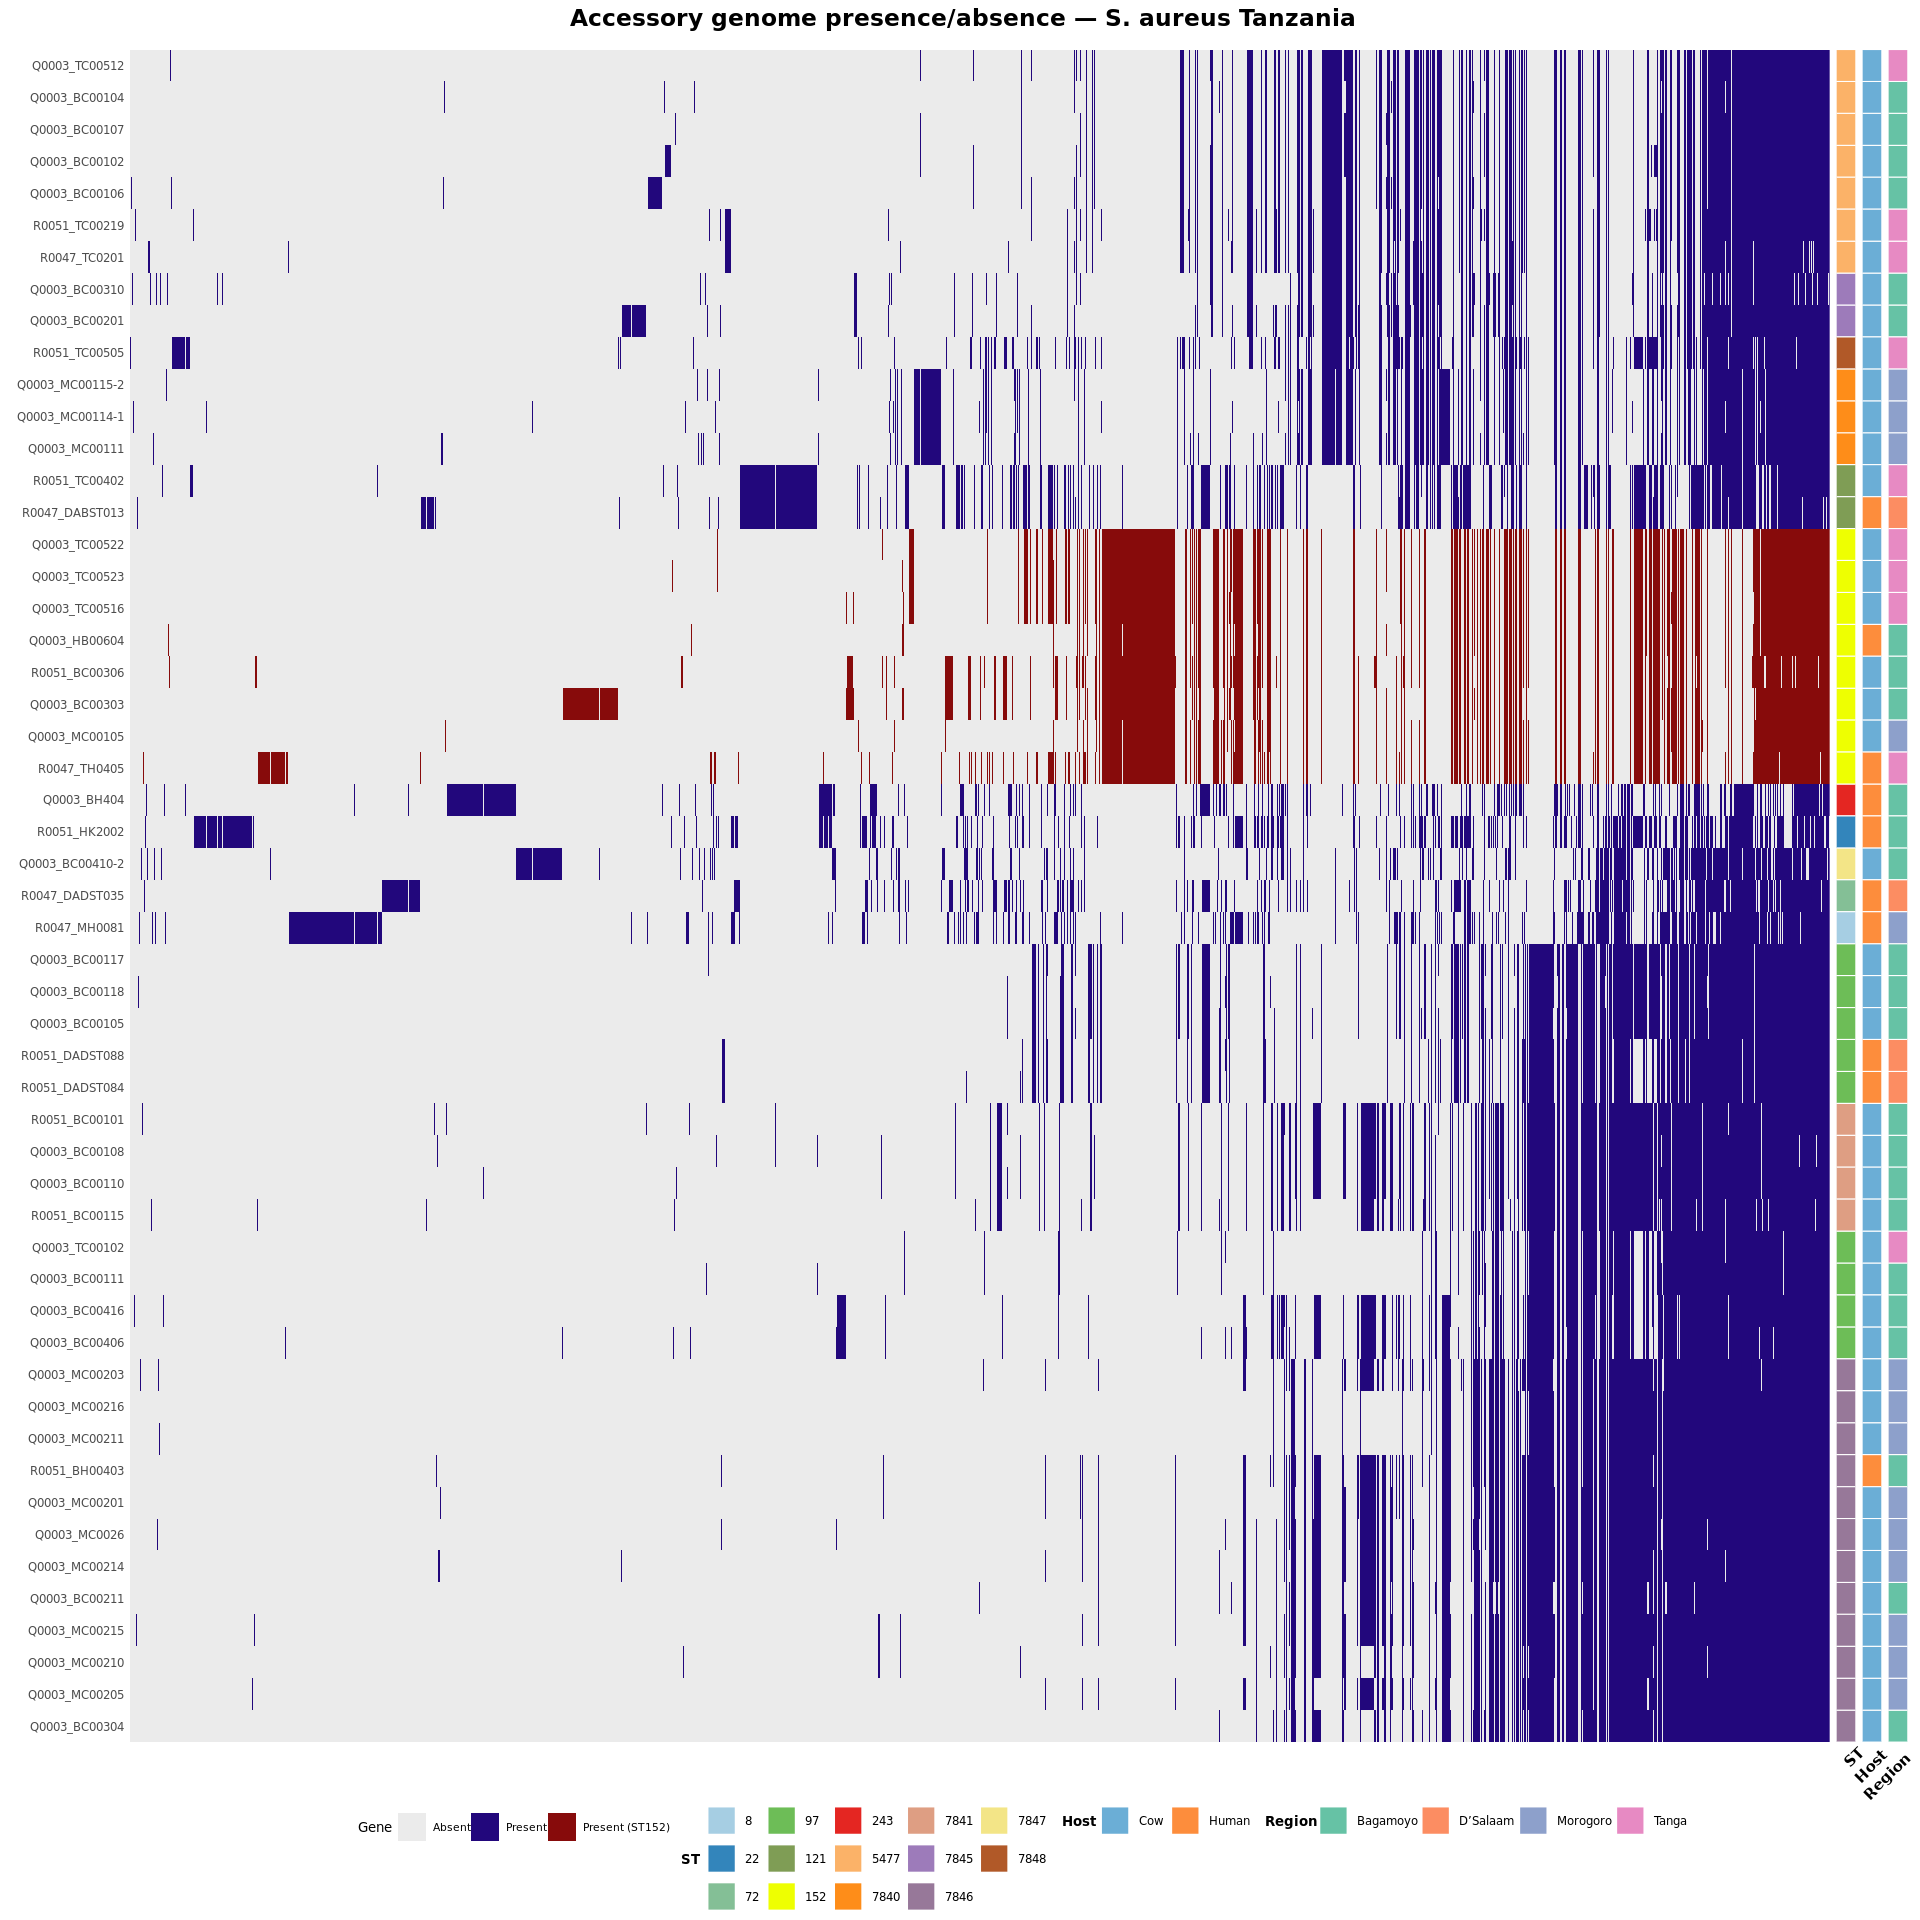

In [40]:
options(repr.plot.width = 16, repr.plot.height = 16)

# ── load ──────────────────────────────────────────────────────────────────────
gpa <- read.delim(file.path(pangenome_dir, "gene_presence_absence.Rtab"),
                  row.names = 1, check.names = FALSE)

# ── match sample order to tree ────────────────────────────────────────────────
samples_in_order <- tip_order[tip_order %in% colnames(gpa)]
gpa_ordered      <- gpa[, samples_in_order]

# ── keep only accessory genes ─────────────────────────────────────────────────
freq          <- rowSums(gpa_ordered) / ncol(gpa_ordered)
gpa_accessory <- gpa_ordered[freq > 0 & freq < 1, ]

# ── sort genes by frequency ───────────────────────────────────────────────────
gene_freq  <- rowSums(gpa_accessory)
gpa_sorted <- gpa_accessory[order(gene_freq, decreasing = TRUE), ]

# ── long format joined with ST info ───────────────────────────────────────────
st_lookup <- meta %>% select(sample, ST)

gpa_long <- gpa_sorted %>%
  tibble::rownames_to_column("gene") %>%
  pivot_longer(-gene, names_to = "sample", values_to = "present") %>%
  left_join(st_lookup, by = "sample") %>%
  mutate(
    sample   = factor(sample, levels = samples_in_order),
    gene     = factor(gene,   levels = rownames(gpa_sorted)),
    present  = as.integer(as.character(present)),
    # tile colour: yellow if ST152+present, blue if other+present, grey if absent
    fill_col = case_when(
      present == 1 & ST == "152" ~ "ST152",
      present == 1               ~ "Present",
      TRUE                       ~ "Absent"
    )
  )

# ── heatmap ───────────────────────────────────────────────────────────────────
p_heatmap <- ggplot(gpa_long, aes(x = gene, y = sample, fill = fill_col)) +
  geom_tile(color = NA) +
  scale_fill_manual(
    values = c("Absent" = "grey92", "Present" = "#22077c", "ST152" = "#870b0b"),
    labels = c("Absent", "Present", "Present (ST152)"),
    name   = "Gene"
  ) +
  scale_x_discrete(expand = c(0, 0), limits = rev) + 
  scale_y_discrete(expand = c(0, 0), limits = rev) +

  theme_minimal(base_size = 8) +
  theme(
    axis.text.x     = element_blank(),
    axis.text.y     = element_text(size = 7),
    axis.ticks      = element_blank(),
    axis.title      = element_blank(),
    panel.grid      = element_blank(),
    legend.position = "bottom",
    plot.margin     = margin(5.5, 2, 0, 5.5)
  )

# ── annotation strips ─────────────────────────────────────────────────────────
annot_ordered <- meta %>%
  filter(sample %in% samples_in_order) %>%
  mutate(label = factor(sample, levels = samples_in_order))

annot_theme <- theme_void() +
  theme(
    axis.title.x    = element_text(size = 9, angle = 45, vjust = 1,
                                   hjust = 1.2, face = "bold"),
    legend.position = "bottom",
    legend.text     = element_text(size = 7),
    legend.title    = element_text(size = 8, face = "bold"),
    plot.margin     = margin(0, 2, 0, 2)
  )

p_st <- ggplot(annot_ordered, aes(y = label, x = 1, fill = factor(ST))) +
  geom_tile(color = "white", linewidth = 0.3) +
  scale_fill_manual(values = st_colours, name = "ST") +
  scale_y_discrete(expand = c(0, 0), limits = rev) +
  scale_x_continuous(expand = c(0, 0)) +
  labs(x = "ST") + annot_theme

p_host <- ggplot(annot_ordered, aes(y = label, x = 1, fill = host)) +
  geom_tile(color = "white", linewidth = 0.3) +
  scale_fill_manual(values = host_colours, name = "Host") +
  scale_y_discrete(expand = c(0, 0), limits = rev) +
  scale_x_continuous(expand = c(0, 0)) +
  labs(x = "Host") + annot_theme

p_region <- ggplot(annot_ordered, aes(y = label, x = 1, fill = region)) +
  geom_tile(color = "white", linewidth = 0.3) +
  scale_fill_manual(values = region_colours, name = "Region") +
  scale_y_discrete(expand = c(0, 0), limits = rev) +
  scale_x_continuous(expand = c(0, 0)) +
  labs(x = "Region") + annot_theme

# ── combine ───────────────────────────────────────────────────────────────────
(p_heatmap + p_st + p_host + p_region +
  plot_layout(widths = c(0.88, 0.01, 0.01, 0.01),
              guides = "collect") &
  theme(legend.position = "bottom")) +
  plot_annotation(
    title = "Accessory genome presence/absence — S. aureus Tanzania",
    theme = theme(plot.title = element_text(size = 14, face = "bold", hjust = 0.5))
  )